In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install underthesea # Thư viện tách từ và xử lý ngôn ngữ tiếng Việt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.9 MB/s eta 0:00:00


In [4]:
# 1. Cài đặt thư viện Kaggle
!pip install -q kaggle

# 2. Tải file kaggle.json lên Colab
from google.colab import files
files.upload() # Chọn file kaggle.json bạn vừa tải về

# 3. Thiết lập thư mục cấu hình cho Kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Tải bộ dữ liệu từ đường dẫn bạn vừa tìm được
!kaggle datasets download -d toreleon/synthetic-vietnamese-students-feedback-corpus

# Giải nén file
!unzip synthetic-vietnamese-students-feedback-corpus.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/toreleon/synthetic-vietnamese-students-feedback-corpus
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 258k/258k [00:00<00:00, 88.3MB/s]

Archive:  synthetic-vietnamese-students-feedback-corpus.zip
  inflating: synthetic_train.csv     
  inflating: synthetic_val.csv       


In [5]:
import pandas as pd

# Đọc file huấn luyện
df_train = pd.read_csv('synthetic_train.csv')

# Xem 5 dòng đầu tiên để xác định tên cột (thường là 'sentence' và 'sentiment')
print(df_train.head())

# Kiểm tra xem có bao nhiêu mẫu cho mỗi loại cảm xúc
print(df_train['sentiment'].value_counts())

                                            sentence sentiment       topic
0  Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...  negative    facility
1  The university's musical and artistic faciliti...   neutral    facility
2  Phương pháp giảng dạy phù hợp với các đối tượn...   neutral  curriculum
3  Chương trình học giúp tôi trở thành một chuyên...  positive  curriculum
4  Tôi nghĩ rằng chương trình đào tạo có thể có t...   neutral  curriculum
sentiment
neutral     2724
negative    2711
positive    2709
Name: count, dtype: int64


In [6]:
!pip install underthesea # Cài đặt thư viện tách từ tiếng Việt [cite: 112]

import re
from underthesea import word_tokenize

def preprocess_vntv(text):
    # 1. Chuyển về chữ thường [cite: 112]
    text = text.lower()
    # 2. Xóa các ký tự đặc biệt, icon và số để giảm nhiễu [cite: 112]
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    # 3. Tách từ tiếng Việt (Word Segmentation) [cite: 112]
    # Ví dụ: "sinh viên" -> "sinh_viên"
    text = word_tokenize(text, format="text")
    return text

# Áp dụng cho toàn bộ tập dữ liệu
df_train['clean_sentence'] = df_train['sentence'].apply(preprocess_vntv)

print("Kết quả sau khi tiền xử lý:")
print(df_train[['sentence', 'clean_sentence']].head())

Kết quả sau khi tiền xử lý:
                                            sentence  \
0  Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...   
1  The university's musical and artistic faciliti...   
2  Phương pháp giảng dạy phù hợp với các đối tượn...   
3  Chương trình học giúp tôi trở thành một chuyên...   
4  Tôi nghĩ rằng chương trình đào tạo có thể có t...   

                                      clean_sentence  
0  đội_ngũ bảo_trì quá thưa_thớt dẫn đến không đả...  
1  the universitys_musical and_artistic facilitie...  
2  phương_pháp giảng_dạy phù_hợp với các đối_tượn...  
3  chương_trình học giúp tôi trở_thành một chuyên...  
4  tôi nghĩ rằng chương_trình đào_tạo có_thể có t...  


In [7]:
df_train.to_csv('cleaned_train.csv', index=False)

In [8]:
!ls

cleaned_train.csv  synthetic_train.csv
drive		   synthetic_val.csv
kaggle.json	   synthetic-vietnamese-students-feedback-corpus.zip
sample_data


In [9]:
# Tải lại bộ dữ liệu từ Kaggle
!kaggle datasets download -d toreleon/synthetic-vietnamese-students-feedback-corpus

# Giải nén
!unzip synthetic-vietnamese-students-feedback-corpus.zip

Dataset URL: https://www.kaggle.com/datasets/toreleon/synthetic-vietnamese-students-feedback-corpus
License(s): Community Data License Agreement - Sharing - Version 1.0
synthetic-vietnamese-students-feedback-corpus.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  synthetic-vietnamese-students-feedback-corpus.zip
replace synthetic_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace synthetic_val.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [10]:
import pandas as pd

# Đọc tệp huấn luyện
df_train = pd.read_csv('synthetic_train.csv')

# Hiển thị 5 dòng đầu để xác nhận cột văn bản và nhãn cảm xúc
print("Dữ liệu gốc:")
print(df_train.head())

Dữ liệu gốc:
                                            sentence sentiment       topic
0  Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...  negative    facility
1  The university's musical and artistic faciliti...   neutral    facility
2  Phương pháp giảng dạy phù hợp với các đối tượn...   neutral  curriculum
3  Chương trình học giúp tôi trở thành một chuyên...  positive  curriculum
4  Tôi nghĩ rằng chương trình đào tạo có thể có t...   neutral  curriculum


In [11]:
# Cài đặt thư viện tách từ tiếng Việt chuyên dụng
!pip install underthesea

import re
from underthesea import word_tokenize

def preprocess_vntv(text):
    # 1. Chuyển về chữ thường để đồng bộ hóa dữ liệu [cite: 112]
    text = str(text).lower()

    # 2. Xóa các ký tự đặc biệt, icon và số để giảm nhiễu
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # 3. Tách từ tiếng Việt (Ví dụ: "sinh viên" -> "sinh_viên")
    text = word_tokenize(text, format="text")
    return text

# Giả sử cột văn bản tên là 'sentence', áp dụng hàm tiền xử lý
df_train['clean_sentence'] = df_train['sentence'].apply(preprocess_vntv)

print("Kết quả sau khi làm sạch và tách từ:")
print(df_train[['sentence', 'clean_sentence']].head())

Kết quả sau khi làm sạch và tách từ:
                                            sentence  \
0  Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...   
1  The university's musical and artistic faciliti...   
2  Phương pháp giảng dạy phù hợp với các đối tượn...   
3  Chương trình học giúp tôi trở thành một chuyên...   
4  Tôi nghĩ rằng chương trình đào tạo có thể có t...   

                                      clean_sentence  
0  đội_ngũ bảo_trì quá thưa_thớt dẫn đến không đả...  
1  the universitys_musical and_artistic facilitie...  
2  phương_pháp giảng_dạy phù_hợp với các đối_tượn...  
3  chương_trình học giúp tôi trở_thành một chuyên...  
4  tôi nghĩ rằng chương_trình đào_tạo có_thể có t...  


In [12]:
# Lưu thành tệp CSV đã được làm sạch
df_train.to_csv('cleaned_train.csv', index=False)
print("Đã lưu tệp cleaned_train.csv thành công!")

Đã lưu tệp cleaned_train.csv thành công!


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# 1. Nạp lại dữ liệu sạch đã lưu
import pandas as pd
df = pd.read_csv('cleaned_train.csv')
# Loại bỏ các dòng bị trống sau khi tiền xử lý (nếu có)
df = df.dropna(subset=['clean_sentence'])

# 2. Chia dữ liệu thành tập Huấn luyện (Train) và Kiểm tra (Test)
# Train (80%) để dạy máy, Test (20%) để chấm điểm máy
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_sentence'], df['sentiment'], test_size=0.2, random_state=42
)

# 3. Khởi tạo và khớp TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Kích thước ma trận TF-IDF của tập huấn luyện:", X_train_tfidf.shape)

Kích thước ma trận TF-IDF của tập huấn luyện: (6515, 5000)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Khởi tạo và huấn luyện mô hình [cite: 115]
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_tfidf, y_train)

# 2. Dự đoán trên tập Test
y_pred = model_lr.predict(X_test_tfidf)

# 3. Đánh giá kết quả ban đầu
print("Độ chính xác của Logistic Regression:", accuracy_score(y_test, y_pred))
print("\nBáo cáo chi tiết:")
print(classification_report(y_test, y_pred))

Độ chính xác của Logistic Regression: 0.8330263965623081

Báo cáo chi tiết:
              precision    recall  f1-score   support

    negative       0.94      0.95      0.95       531
     neutral       0.76      0.74      0.75       533
    positive       0.79      0.81      0.80       565

    accuracy                           0.83      1629
   macro avg       0.83      0.83      0.83      1629
weighted avg       0.83      0.83      0.83      1629



In [15]:
import joblib
joblib.dump(model_lr, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [16]:
from sklearn.svm import SVC

# 1. Khởi tạo và huấn luyện SVM (Dùng kernel='linear' thường rất tốt cho văn bản)
model_svm = SVC(kernel='linear', C=1.0)
model_svm.fit(X_train_tfidf, y_train)

# 2. Dự đoán và chấm điểm
y_pred_svm = model_svm.predict(X_test_tfidf)

print("Độ chính xác của SVM:", accuracy_score(y_test, y_pred_svm))
print("\nBáo cáo chi tiết SVM:")
print(classification_report(y_test, y_pred_svm))

Độ chính xác của SVM: 0.8348680171884592

Báo cáo chi tiết SVM:
              precision    recall  f1-score   support

    negative       0.95      0.95      0.95       531
     neutral       0.76      0.75      0.76       533
    positive       0.80      0.80      0.80       565

    accuracy                           0.83      1629
   macro avg       0.84      0.84      0.84      1629
weighted avg       0.83      0.83      0.83      1629



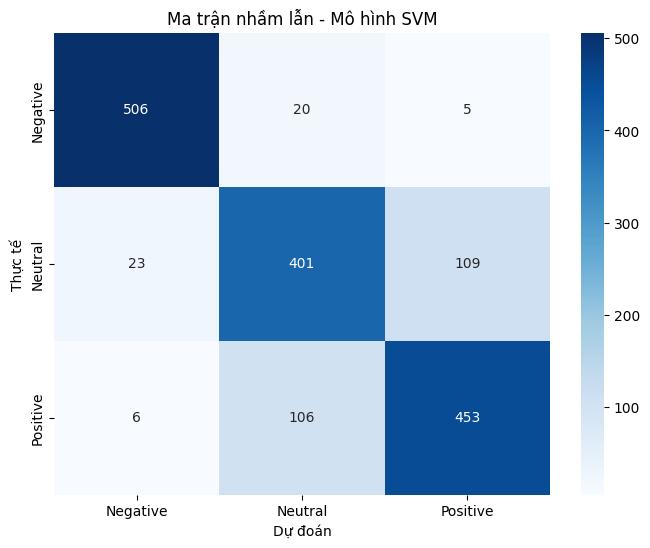

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tạo ma trận nhầm lẫn cho SVM
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Ma trận nhầm lẫn - Mô hình SVM')
plt.show()

In [18]:
import joblib

# Lưu mô hình SVM và bộ biến đổi TF-IDF
joblib.dump(model_svm, 'best_sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("Đã lưu mô hình tối ưu nhất!")

Đã lưu mô hình tối ưu nhất!


In [19]:
!pip install streamlit -q
!pip install pyngrok
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 21.2 MB/s eta 0:00:00


In [20]:
%%writefile app.py
import streamlit as st
import joblib
import re
from underthesea import word_tokenize

# 1. Load mô hình và bộ biến đổi đã lưu ở bước trước
model = joblib.load('best_sentiment_model.pkl')
tfidf = joblib.load('tfidf_vectorizer.pkl')

# 2. Hàm tiền xử lý (phải giống hệt lúc huấn luyện)
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = word_tokenize(text, format="text")
    return text

# 3. Giao diện Web
st.title("😊 Hệ thống Phân loại Cảm xúc Tiếng Việt")
st.write("Đồ án tốt nghiệp - SV thực hiện: Nguyễn Thành Đô")

input_text = st.text_input("Nhập câu văn cần phân tích:", "Giảng viên nhiệt tình, bài giảng hay.")

if st.button("Phân tích ngay"):
    # Tiền xử lý câu nhập vào
    clean_input = preprocess_text(input_text)
    # Biến đổi TF-IDF
    vectorized_input = tfidf.transform([clean_input])
    # Dự đoán
    prediction = model.predict(vectorized_input)[0]

    # Hiển thị kết quả kèm icon
    if prediction == 'positive' or prediction == 2:
        st.success(f"Kết quả: TÍCH CỰC 😊")
    elif prediction == 'negative' or prediction == 0:
        st.error(f"Kết quả: TIÊU CỰC 😡")
    else:
        st.warning(f"Kết quả: TRUNG LẬP 😐")

Writing app.py


In [23]:
# Lấy địa chỉ IP công cộng của Colab (bạn sẽ cần nó để dán vào trang web)
!wget -q -O - ipv4.icanhazip.com

# Chạy Streamlit ở chế độ nền và mở tunnel
!streamlit run app.py & npx localtunnel --port 8501

136.111.248.9
⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://thick-llamas-tease.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.111.248.9:8501

  Stopping...
^C


In [22]:
import joblib
import re
from underthesea import word_tokenize

# 1. Nạp mô hình và bộ biến đổi đã lưu (Kết quả Tuần 10)
model = joblib.load('best_sentiment_model.pkl')
tfidf = joblib.load('tfidf_vectorizer.pkl')

# 2. Hàm tiền xử lý (Phải đồng nhất với Tuần 2) [cite: 16, 36]
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = word_tokenize(text, format="text")
    return text

# 3. Vòng lặp thử nghiệm Demo
print("--- HỆ THỐNG PHÂN LOẠI CẢM XÚC (OFFLINE DEMO) ---")
print("Nhập 'exit' để dừng lại.\n")

while True:
    user_input = input("Nhập câu văn của bạn: ")
    if user_input.lower() == 'exit':
        break

    # Thực hiện quy trình Pipeline [cite: 42]
    clean_input = preprocess_text(user_input)
    vectorized_input = tfidf.transform([clean_input])
    prediction = model.predict(vectorized_input)[0]

    # Hiển thị kết quả dự kiến [cite: 46]
    label_map = {0: "TIÊU CỰC 😡", 1: "TRUNG LẬP 😐", 2: "TÍCH CỰC 😊",
                 'negative': "TIÊU CỰC 😡", 'neutral': "TRUNG LẬP 😐", 'positive': "TÍCH CỰC 😊"}

    result = label_map.get(prediction, prediction)
    print(f">> Dự đoán: {result}")
    print("-" * 30)

--- HỆ THỐNG PHÂN LOẠI CẢM XÚC (OFFLINE DEMO) ---
Nhập 'exit' để dừng lại.

Nhập câu văn của bạn: Đội ngũ bảo trì quá thưa thớt dẫn đến không đảm bảo chất lượng
>> Dự đoán: TIÊU CỰC 😡
------------------------------
Nhập câu văn của bạn: Giảng viên có chuyên môn nên giảng bài rất dễ hiểu
>> Dự đoán: TRUNG LẬP 😐
------------------------------
Nhập câu văn của bạn: sản phẩm này tốt
>> Dự đoán: TRUNG LẬP 😐
------------------------------
Nhập câu văn của bạn: Chương trình học đã giúp tôi trở thành một chuyên viên
>> Dự đoán: TÍCH CỰC 😊
------------------------------
Nhập câu văn của bạn: Chương trình học không dạy được gì cho tôi
>> Dự đoán: TIÊU CỰC 😡
------------------------------
Nhập câu văn của bạn: sản phẩm này không tốt nên chất lượng không được đảm bảo
>> Dự đoán: TIÊU CỰC 😡
------------------------------


KeyboardInterrupt: Interrupted by user